Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

In [1]:
from setup import *

In [2]:
# Collision theory 
m_CO = 28.01e-3 / N_A # Mass of CO molecule in kg
P_atm_to_Pa = 101325 # 1 atm to Pa
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
sticking_coeff = 0.8
k1_collision = sticking_coeff * A_site * P_atm_to_Pa / np.sqrt(2*np.pi*m_CO*kb_J*T)
log_k1_collision = np.log(k1_collision)

# Smoluchowski theory
henry_constant = 9.3e-4 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
k1_smol = 2 * np.pi * diffusion_coefficient * (3e-10) * henry_constant * N_A # 3e-10 m is the effective radius of the Pt site
log_k1_smol = np.log(k1_smol)

# 1D Fickian diffusion 
henry_constant = 9.3e-4 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
delta_BL = 10e-6 # m for a flag in a stirred beaker
k1_fick = diffusion_coefficient * henry_constant * N_A * A_site / delta_BL
log_k1_fick = np.log(k1_fick)

# ER 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.27,15
,3000,0,0.25,15
,3000,0,0.25,15
,3000,0,0.25,15


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 575 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -358.65   162.35
p_loo       70.10        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      570   99.1%
   (0.70, 1]   (bad)         2    0.3%
   (1, Inf)   (very bad)    3    0.5%



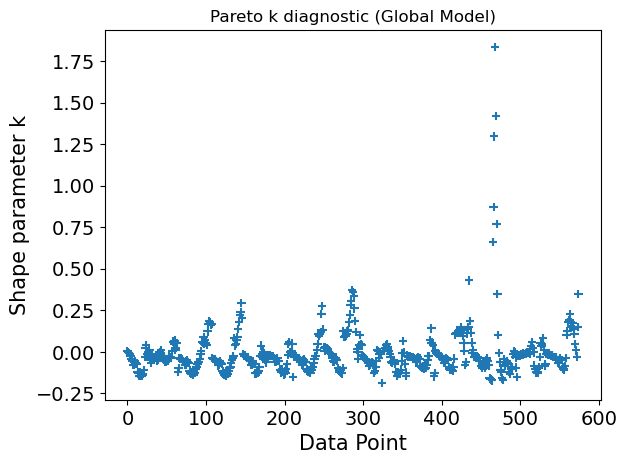

In [3]:
with pm.Model() as ER_1_2: # Winner winner chicken dinner 
    '''
    1. CO + * <-> CO* (Fick) (Irr)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    # deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7) # at 0V_SHE

    # Thermodynamics 
    # deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    # log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    # term_CO = log_k1 + np.log(P_CO_in) - pt.logaddexp(log_k1 - log_K1, log_k2 + np.log(C_KOH_in))
    term_CO = log_k1 + np.log(P_CO_in) - (log_k2 + np.log(C_KOH_in))
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

trace_ER_1_2, loo_ER_1_2 = fit_and_evaluate(ER_1_2, target_accept=0.99)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  0.058  0.001   0.056    0.061        0.0      0.0    1889.0    2193.0    1.0
beta_2     0.345  0.001   0.342    0.347        0.0      0.0    1537.0    1820.0    1.0
Gact2_0    0.743  0.000   0.742    0.743        0.0      0.0    1619.0    2137.0    1.0


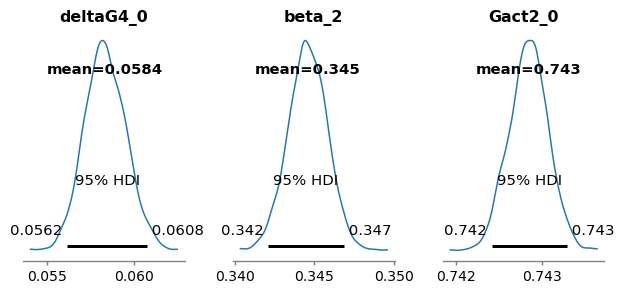

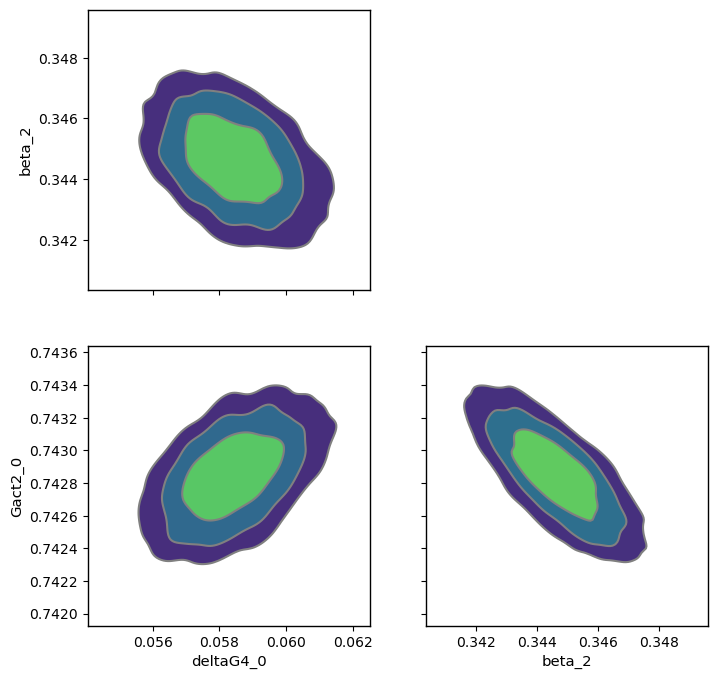

Sampling: [rate]


rate: 0.906


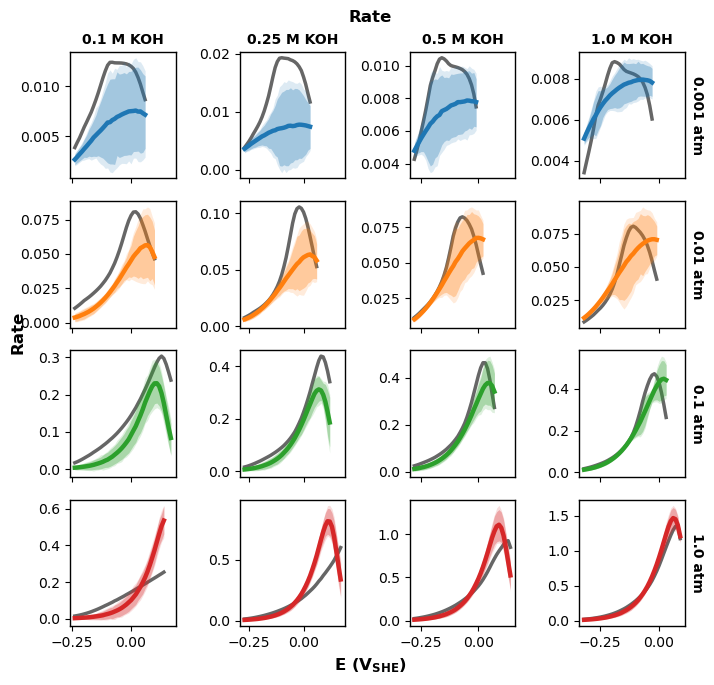

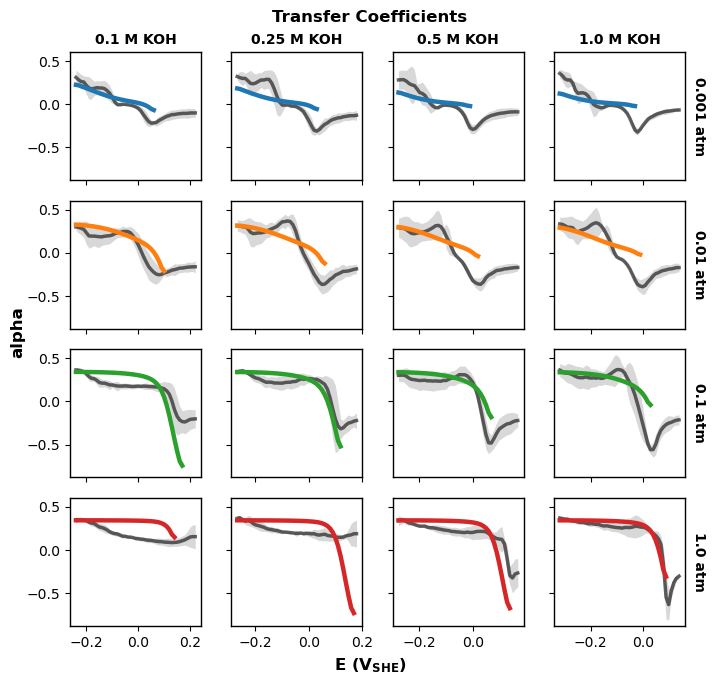

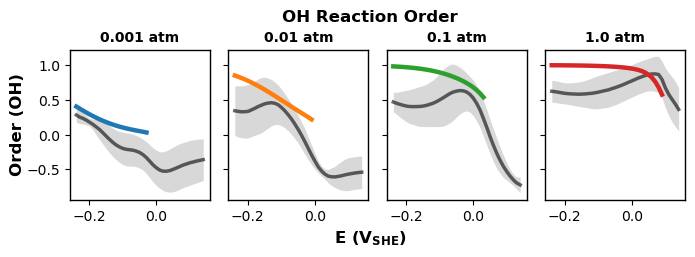

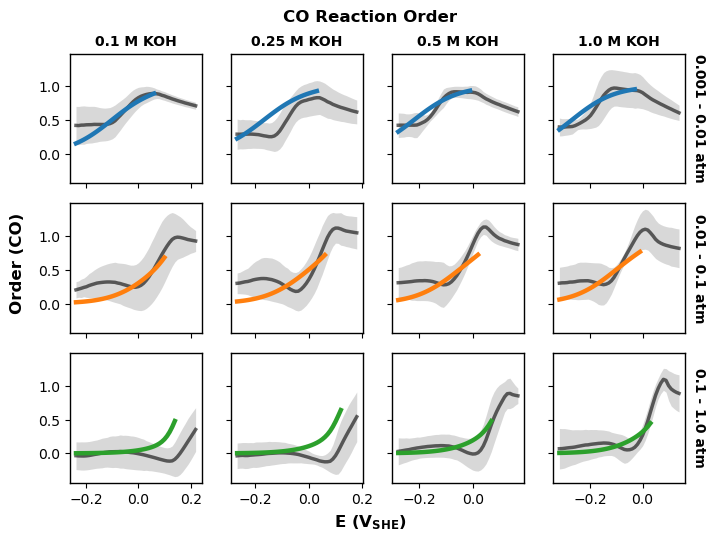

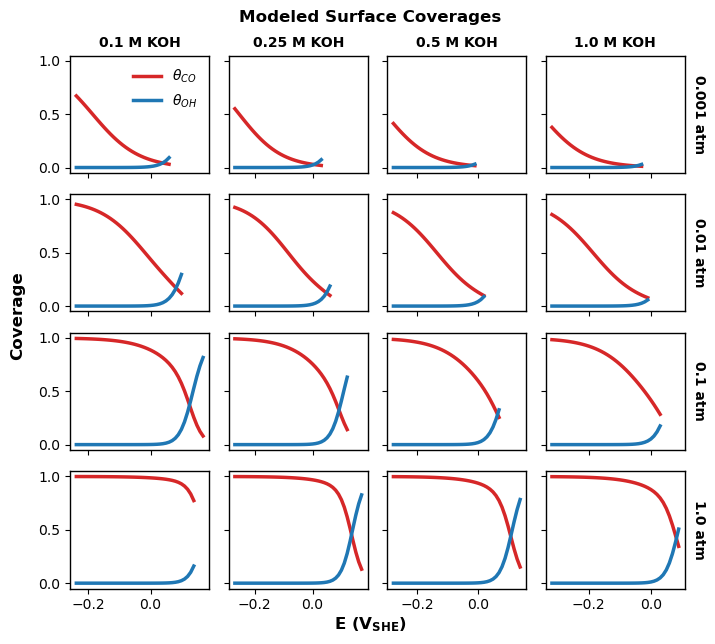

In [4]:
ppc_ER_1_2 = plot_posteriors(trace_ER_1_2, ER_1_2, plot_target)
plot_model_fits(trace_ER_1_2, ppc_ER_1_2); plot_coverages(trace_ER_1_2)

# ER LH 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.22,15
,3000,0,0.23,7
,3000,0,0.26,15
,3000,0,0.26,15


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 575 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -360.15   162.62
p_loo       72.03        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      571   99.3%
   (0.70, 1]   (bad)         1    0.2%
   (1, Inf)   (very bad)    3    0.5%



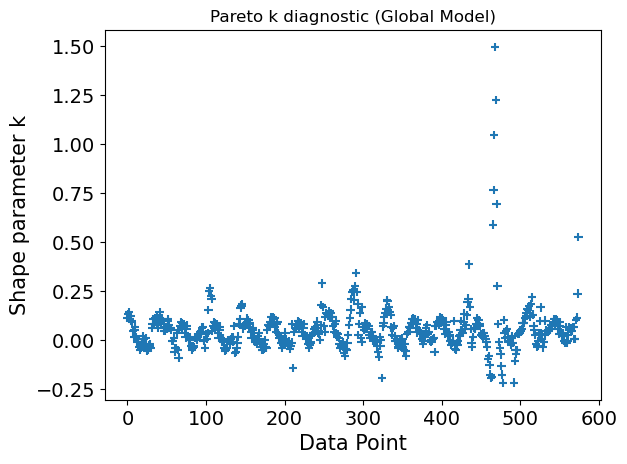

In [5]:
with pm.Model() as ER_LH_1_2: # LH is dead in the water
    '''
    1. CO + * <-> CO* (Fick) (Irr)
    2a. CO* + OH- -> COOH* + (e-) (SSA)
    2b. CO* + OH* -> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    # deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.75, sigma=0.1, lower=0.7) # at 0V_SHE
    Gact2_LH_0 = pm.TruncatedNormal('Gact2_LH_0', mu=0.75, sigma=0.1, lower=0.7)

    # Thermodynamics 
    # deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    # log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_OH = log_K4 + np.log(C_KOH_in)
    gamma_OH_lin = pt.exp(term_OH)
    k1_fwd_lin = pt.exp(log_k1 + np.log(P_CO_in))
    k2_ER_lin = pt.exp(log_k2_ER + np.log(C_KOH_in))
    k2_LH_lin = pt.exp(log_k2_LH + term_OH)
    site_block = 1.0 + gamma_OH_lin
    a_term = k2_ER_lin
    b_term = k2_ER_lin * site_block + k2_LH_lin - k1_fwd_lin
    c_term = - k1_fwd_lin * site_block
    gamma_CO_lin = (-b_term + pt.sqrt(b_term**2 - 4 * a_term * c_term)) / (2 * a_term)
    term_CO = pt.log(gamma_CO_lin)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    
    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    rate_ER = log_k2_ER + np.log(C_KOH_in) + log_theta_CO
    rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_model = pt.logaddexp(rate_ER, rate_LH)
    log_rate = observables(log_rate_model) 

trace_ER_LH_1_2, loo_ER_LH_1_2 = fit_and_evaluate(ER_LH_1_2, target_accept=0.99)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.058  0.001   0.056    0.061      0.000    0.000    2170.0    2468.0    1.0
beta_2      0.345  0.001   0.342    0.347      0.000    0.000    1491.0    2210.0    1.0
Gact2_ER_0  0.743  0.000   0.742    0.743      0.000    0.000    1557.0    1870.0    1.0
Gact2_LH_0  0.893  0.048   0.815    0.984      0.001    0.001    3531.0    2574.0    1.0


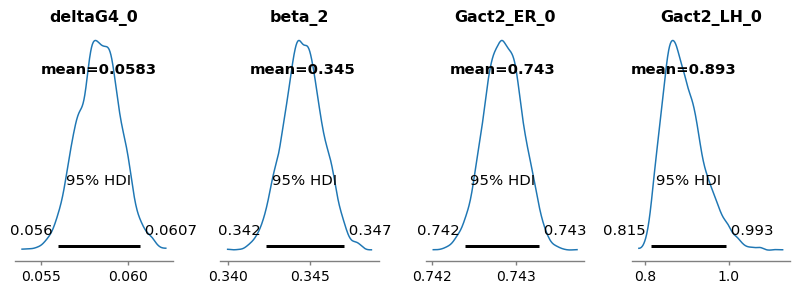

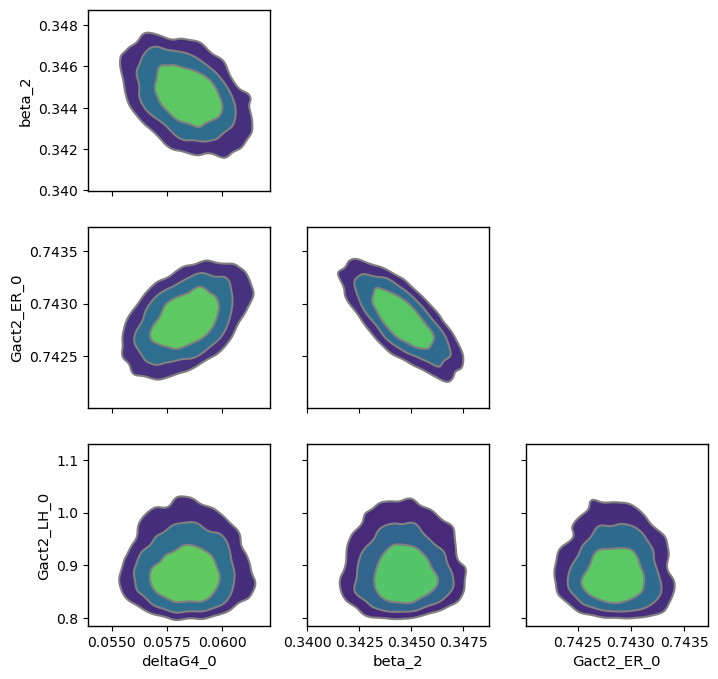

Sampling: [rate]


rate: 0.906


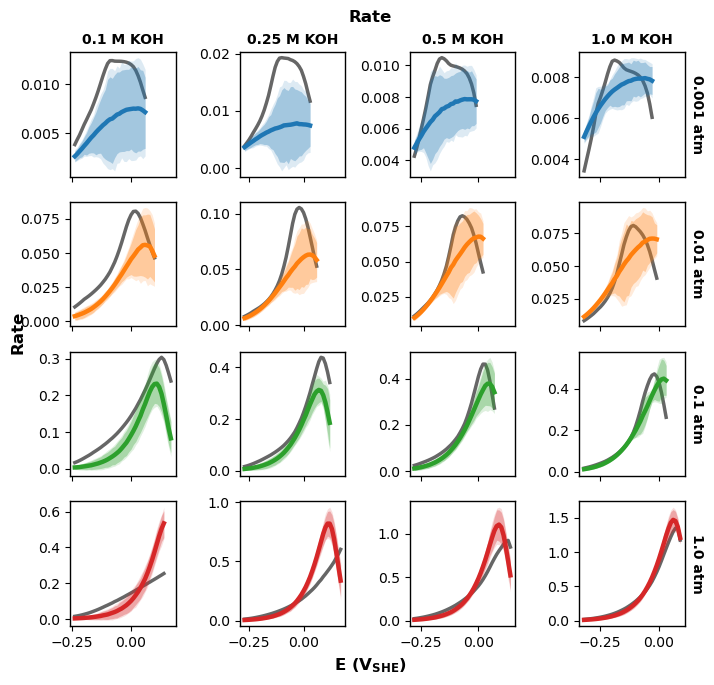

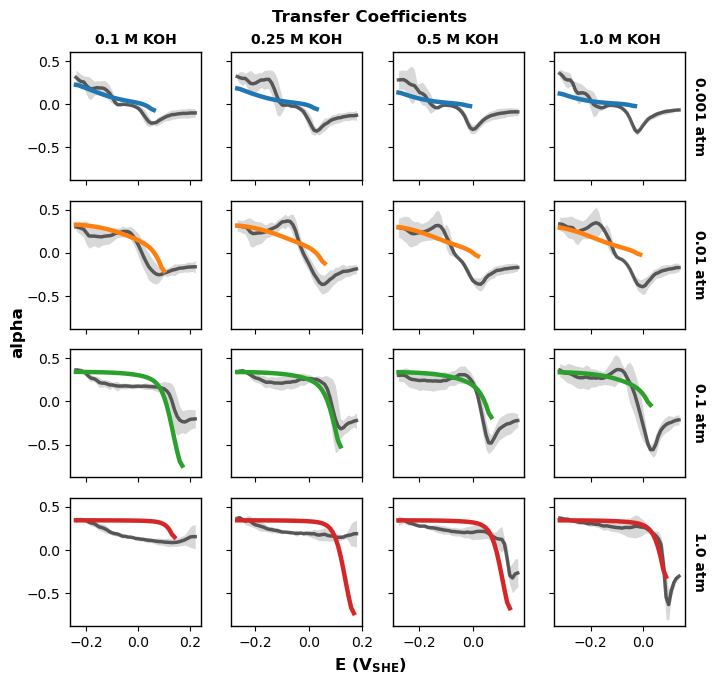

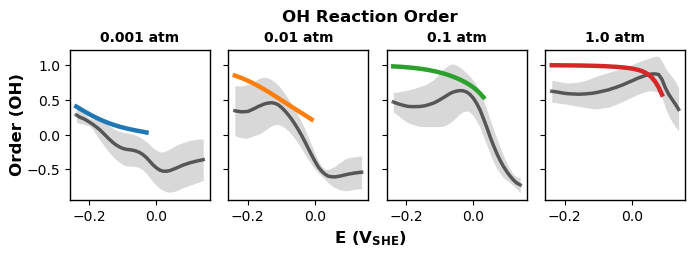

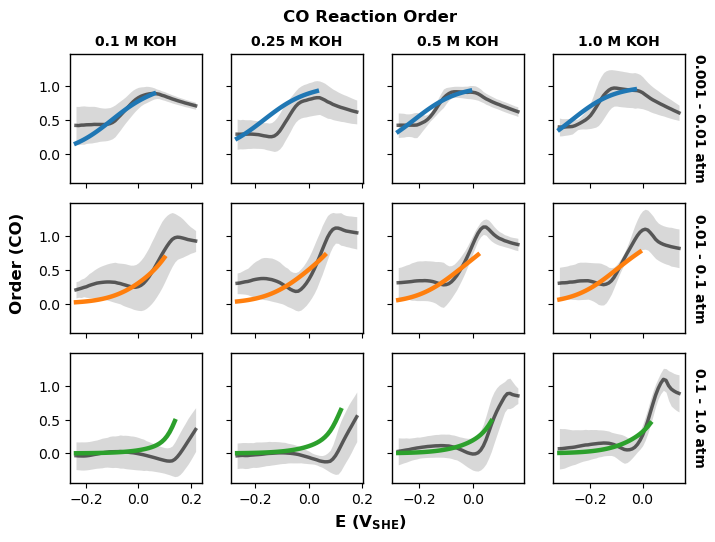

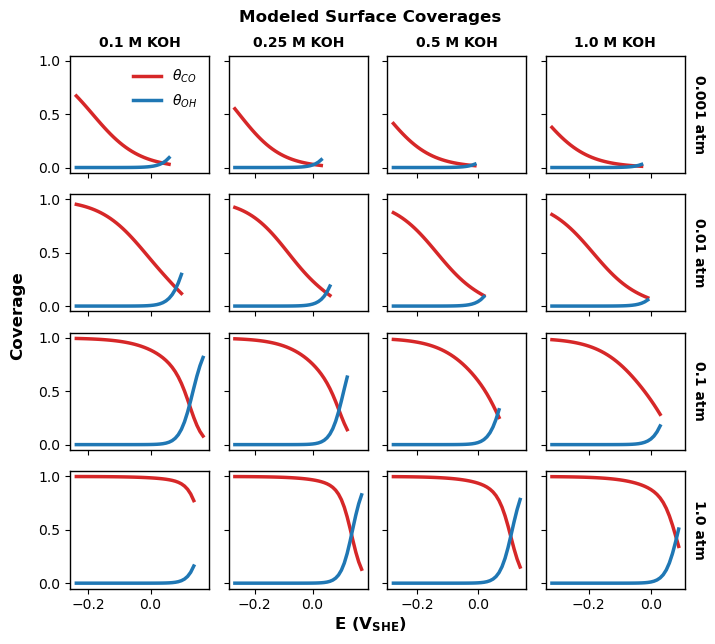

In [6]:
ppc_ER_LH_1_2 = plot_posteriors(trace_ER_LH_1_2, ER_LH_1_2, plot_target)
plot_model_fits(trace_ER_LH_1_2, ppc_ER_LH_1_2); plot_coverages(trace_ER_LH_1_2)

# ER 1 2 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.07,127
,3000,0,0.08,31
,3000,0,0.08,63
,3000,0,0.07,31


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 575 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   407.40    98.08
p_loo       53.77        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      571   99.3%
   (0.70, 1]   (bad)         3    0.5%
   (1, Inf)   (very bad)    1    0.2%



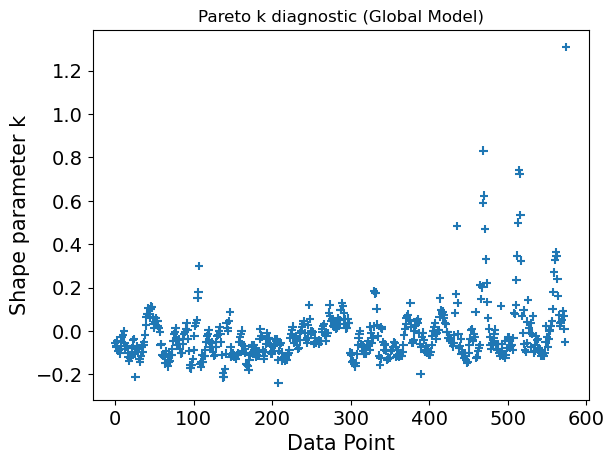

In [7]:
with pm.Model() as ER_1_2_3: # Overfitting? 
    '''
    1. CO + * <-> CO* (Fick) (Irr)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA) (Irr)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    # deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=-0.1, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    beta_3 = pm.Uniform('beta_3', lower=0.25, upper=1)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7) # at 0V_SHE
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.55, sigma=0.1, lower=0) # at 0V_SHE

    # Thermodynamics 
    # deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2 = deltaG2_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    # log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k1 = log_k1_fick
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    log_denom_COOH = pt.logaddexp(log_k2 - log_K2, log_k3 + np.log(C_KOH_in))
    log_k2_k3_term = log_k2 + log_k3 + 2*np.log(C_KOH_in) - log_denom_COOH
    term_CO = log_k1 + np.log(P_CO_in) - log_k2_k3_term
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2 + np.log(C_KOH_in) - log_denom_COOH + term_CO
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + np.log(C_KOH_in) + log_theta_COOH
    log_rate = observables(log_rate_model) 

trace_ER_1_2_3, loo_ER_1_2_3 = fit_and_evaluate(ER_1_2_3, target_accept=0.99)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  0.088  0.004   0.081    0.095      0.000    0.000    1091.0    1789.0   1.00
deltaG2_0 -0.438  0.033  -0.500   -0.384      0.001    0.001    1806.0    1328.0   1.00
beta_2     0.216  0.010   0.197    0.233      0.000    0.000     505.0    1016.0   1.01
beta_3     0.573  0.020   0.537    0.609      0.001    0.001     428.0     801.0   1.01
Gact2_0    0.743  0.001   0.742    0.744      0.000    0.000     507.0    1189.0   1.01
Gact3_0    0.678  0.006   0.667    0.690      0.000    0.000     429.0     837.0   1.01


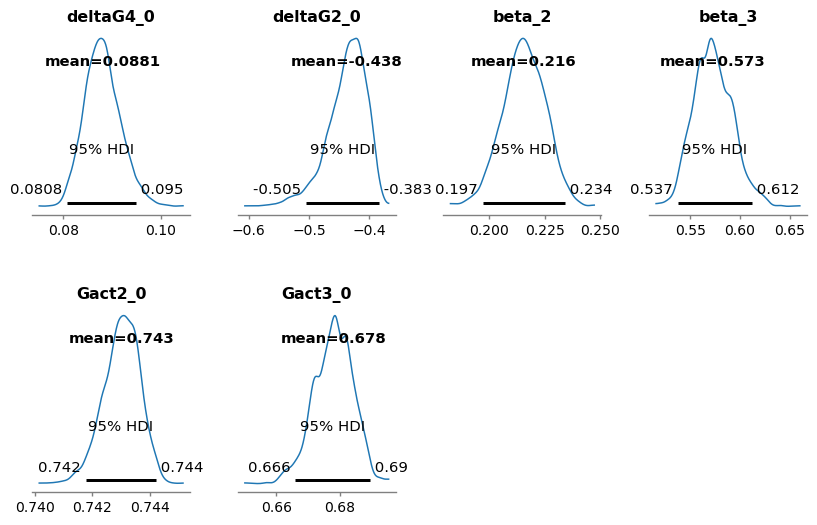

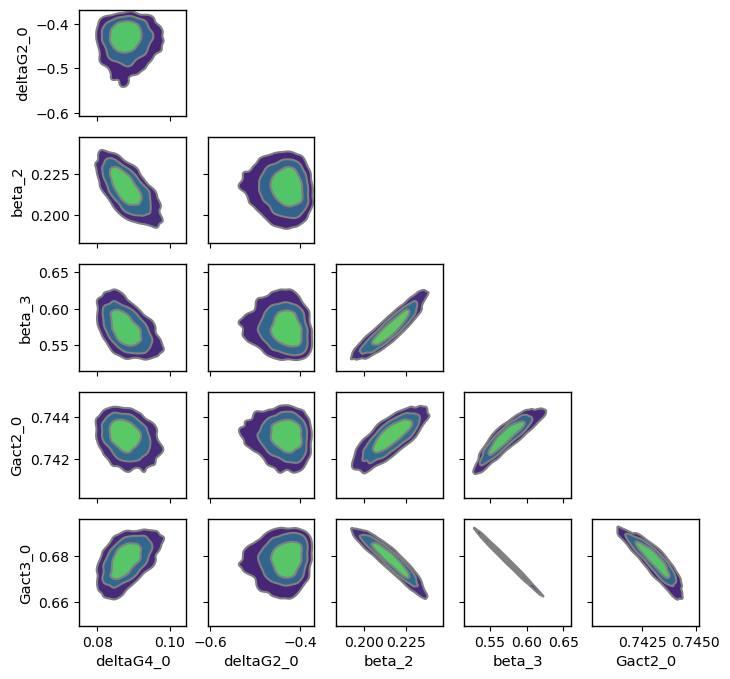

Sampling: [rate]


rate: 0.954


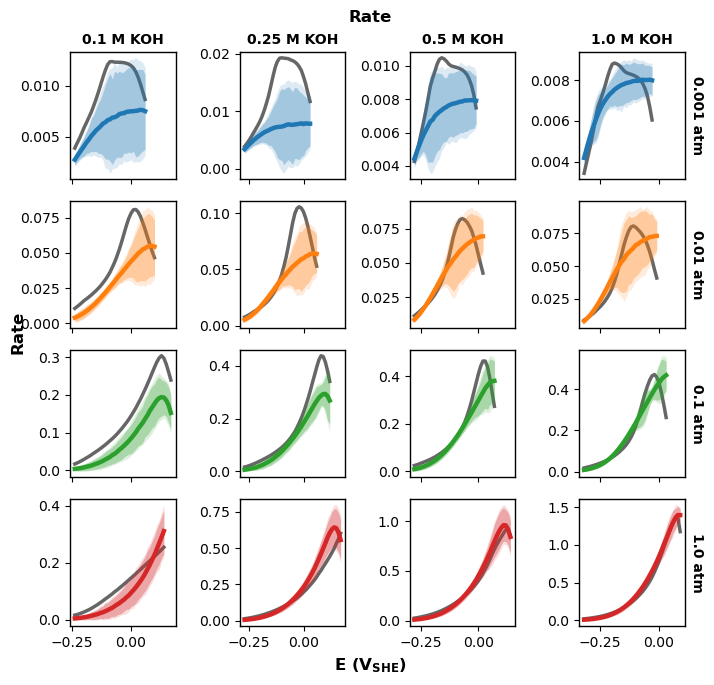

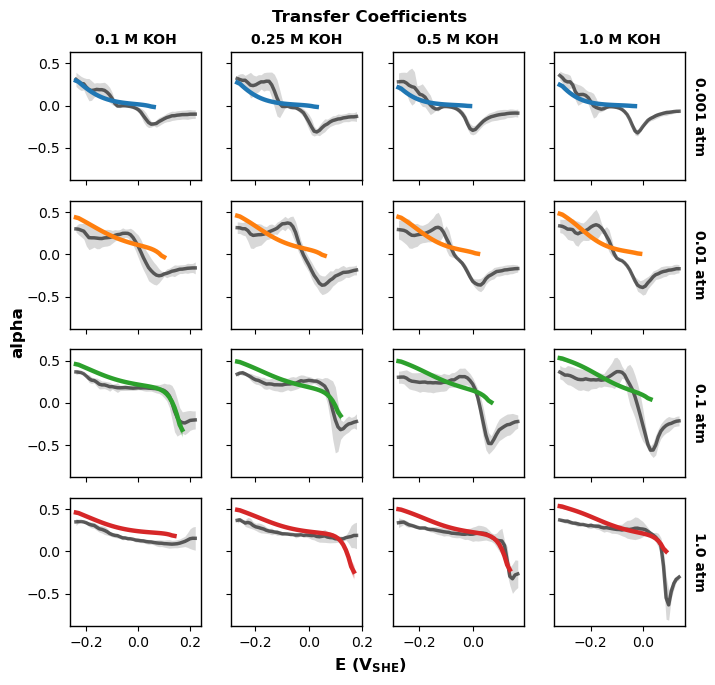

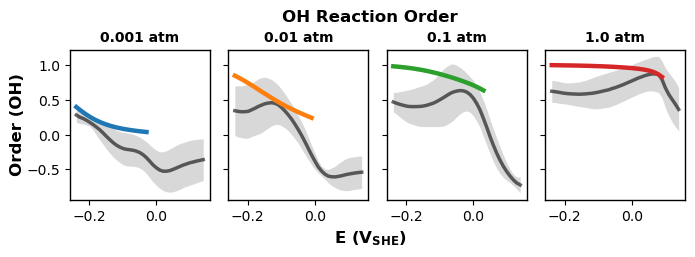

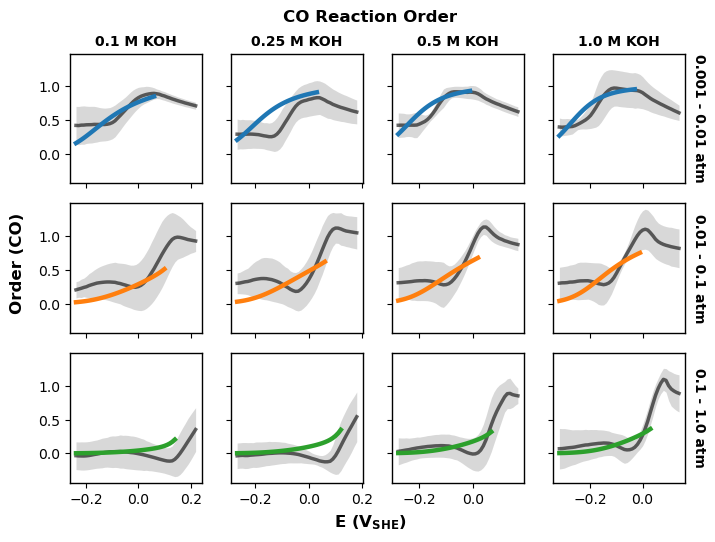

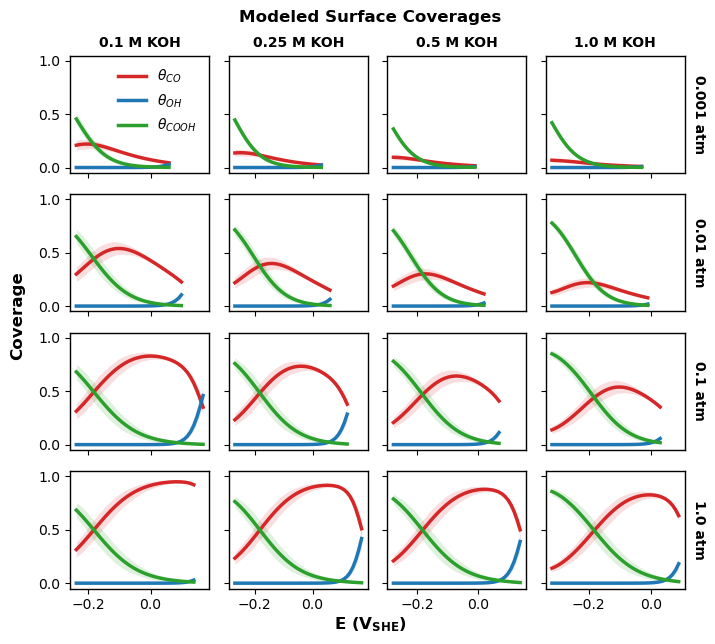

In [8]:
ppc_ER_1_2_3 = plot_posteriors(trace_ER_1_2_3, ER_1_2_3, plot_target)
plot_model_fits(trace_ER_1_2_3, ppc_ER_1_2_3); plot_coverages(trace_ER_1_2_3)

# ER 1 2 Kinetics

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.12,31
,3000,0,0.16,23
,3000,0,0.16,7
,3000,0,0.13,15


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 575 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -363.19   163.38
p_loo       74.90        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      570   99.1%
   (0.70, 1]   (bad)         2    0.3%
   (1, Inf)   (very bad)    3    0.5%



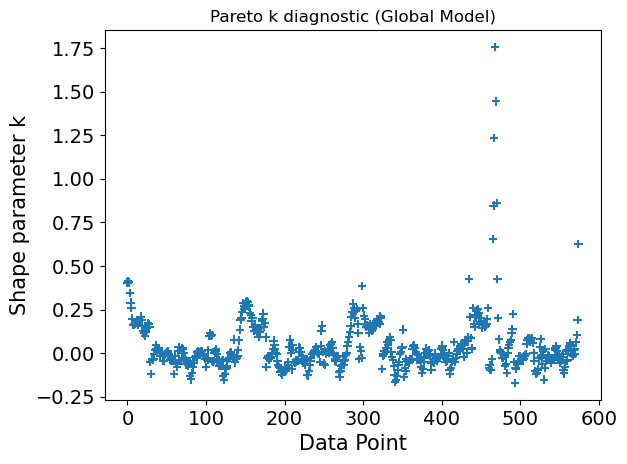

In [9]:
with pm.Model() as ER_1_2_kin: # Shows that CO adsorption is only limited by MT, desorption is slow, adsorption is kinetically fast
    '''
    1. CO + * <-> CO* (Mass Transfer + Kinetic Adsorption/Desorption)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.7, sigma=0.1, lower=0) # Kinetic barrier for adsorption
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1_fick_term = log_k1_fick 
    log_k1_kin = np.log(kb_J*T/h) - Gact1_0/(kb_eV*T)
    log_k1_eff = -pt.logaddexp(-log_k1_fick_term, -log_k1_kin) 
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    log_denom_CO = pt.logaddexp(log_k1_kin - log_K1, log_k2 + np.log(C_KOH_in))
    term_CO = log_k1_eff + np.log(P_CO_in) - log_denom_CO
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

trace_ER_1_2_kin, loo_ER_1_2_kin = fit_and_evaluate(ER_1_2_kin, target_accept=0.99)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.608  0.118  -0.831   -0.424      0.004    0.003     892.0    1049.0    1.0
deltaG4_0  0.058  0.001   0.056    0.061      0.000    0.000    2227.0    2522.0    1.0
Gact1_0    0.496  0.036   0.429    0.556      0.001    0.001    1568.0    1066.0    1.0
beta_2     0.345  0.001   0.342    0.347      0.000    0.000    1785.0    2493.0    1.0
Gact2_0    0.743  0.000   0.742    0.743      0.000    0.000    1802.0    2467.0    1.0


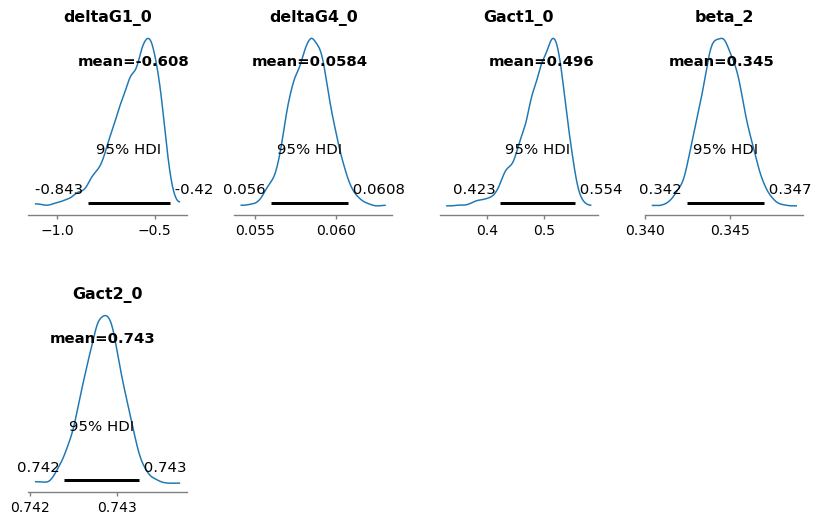

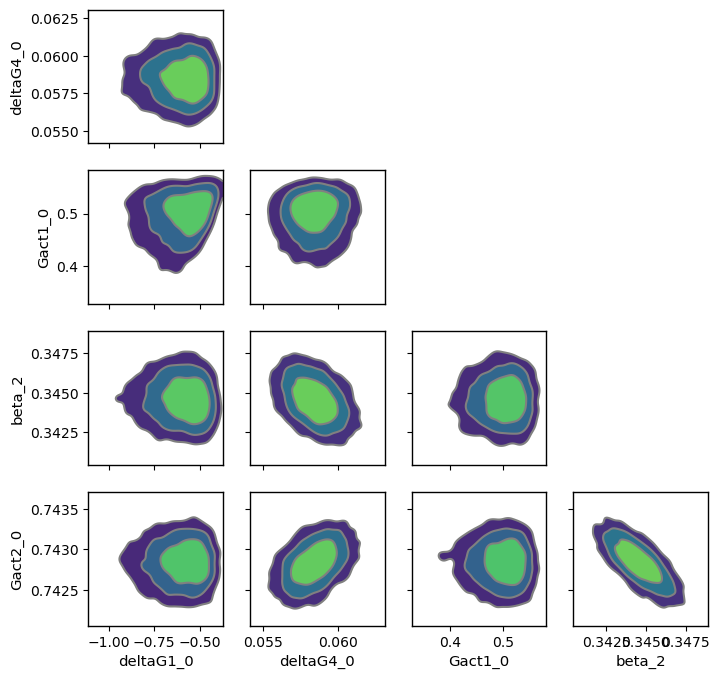

Sampling: [rate]


rate: 0.906


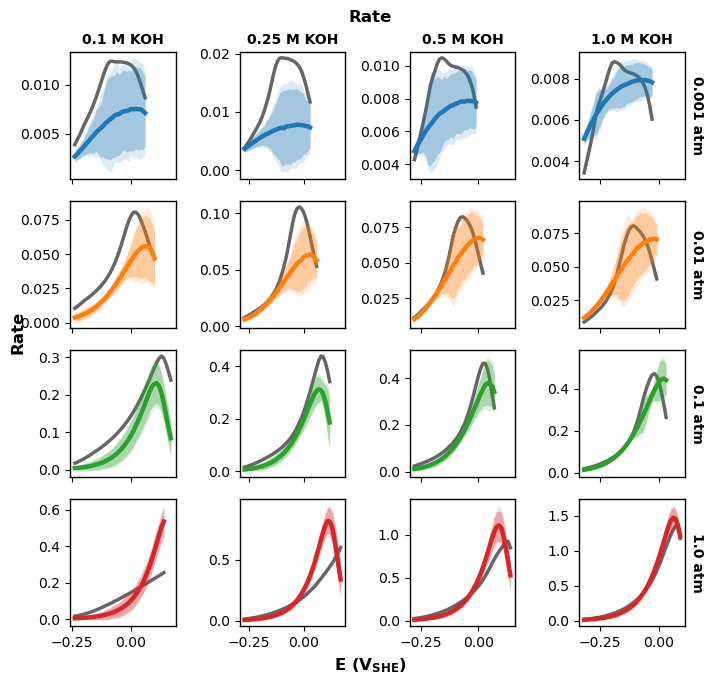

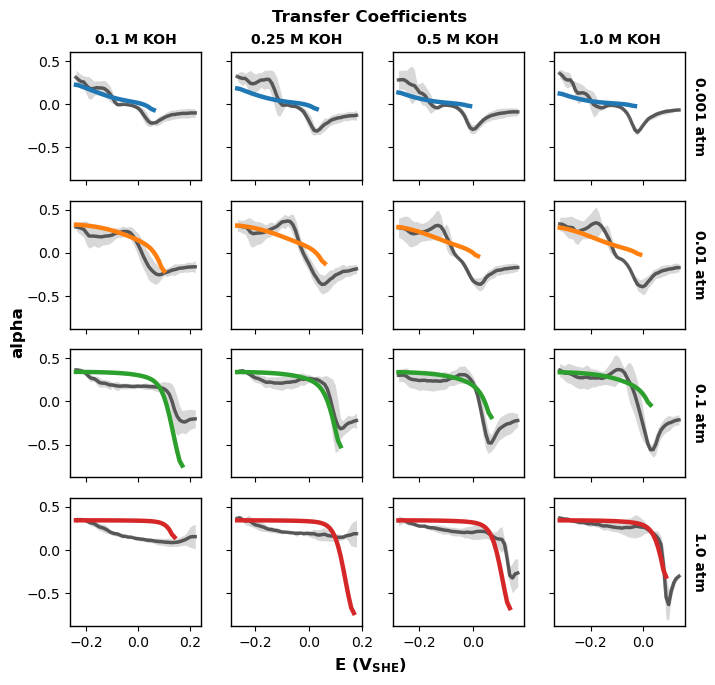

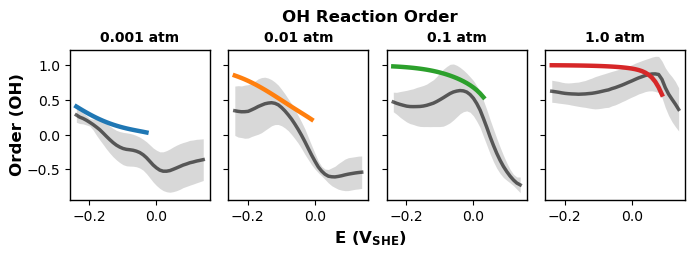

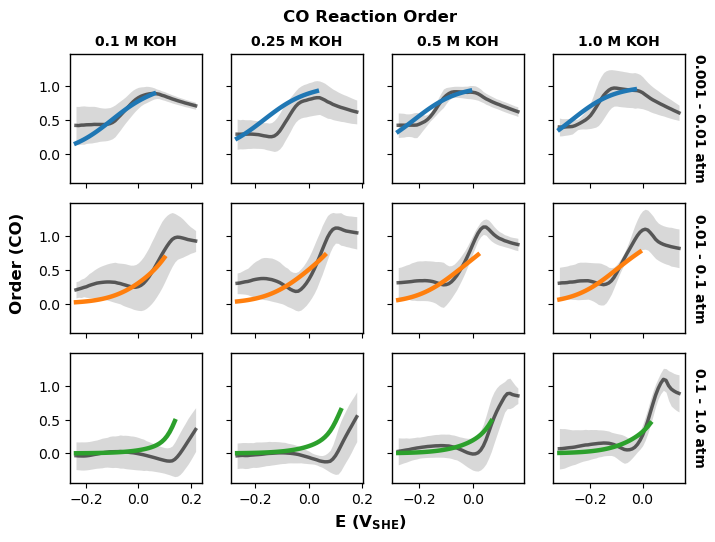

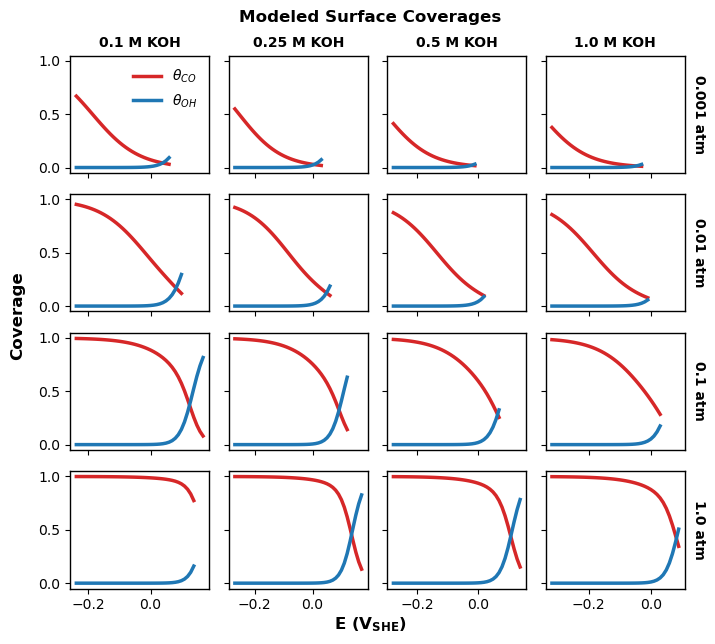

In [10]:
ppc_ER_1_2_kin = plot_posteriors(trace_ER_1_2_kin, ER_1_2_kin, plot_target)
plot_model_fits(trace_ER_1_2_kin, ppc_ER_1_2_kin); plot_coverages(trace_ER_1_2_kin)

# ER 1 2 Lateral

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.19,31
,3000,0,0.16,7
,3000,0,0.17,31
,3000,0,0.20,23


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 575 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -203.50   140.60
p_loo       62.01        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      572   99.5%
   (0.70, 1]   (bad)         1    0.2%
   (1, Inf)   (very bad)    2    0.3%



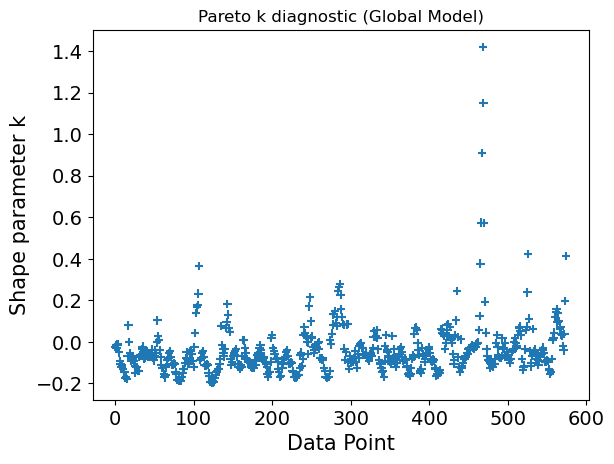

In [11]:
with pm.Model() as ER_1_2_lateral: # OH-OH lateral interactions are good 
    '''
    1. CO + * -> CO* (Fick) (Irr) (Unaffected by lateral interactions)
    2. CO* + OH- -> COOH* + (e-) (SSA with BEP - Lateral interactions speed this up)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA Frumkin)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1)
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7) 
    z_CO = pt.as_tensor_variable(0.0) # pm.TruncatedNormal('z_CO', lower=0, mu=0.1, sigma=0.1)
    z_OH = pm.TruncatedNormal('z_OH', lower=0, mu=0.1, sigma=0.1) # pt.as_tensor_variable(0.0)
    z_cross = pt.as_tensor_variable(0.0) # pm.TruncatedNormal('z_cross', lower=0, mu=0.1, sigma=0.1)

    bep_alpha = 0.65 # BEP transfer coefficient (how much repulsion lowers Gact2)

    # Thermodynamics
    deltaG4_base = deltaG4_0 - E_in
    Gact2_base = Gact2_0 - beta_2 * E_in
    log_K4_base = -deltaG4_base / (kb_eV * T)
    log_k1_base = log_k1_fick # Pure Fickian diffusion
    log_k2_base = np.log(kb_J * T / h) - Gact2_base / (kb_eV * T)

    # Initial guess: Langmuir (No interactions)
    term_CO_base = log_k1_base + np.log(P_CO_in) - (log_k2_base + np.log(C_KOH_in))
    term_OH_base = log_K4_base + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO_base)   
    log_theta_init = -pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_init)
    theta_OH_guess = pt.exp(term_OH_base + log_theta_init)

    # Iterative solver setup 
    n_iter_steps = 24
    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.05))
    
    def frumkin_step(damp, theta_CO_prev, theta_OH_prev, log_k1_base, log_k2_base, log_K4_base, z_CO, z_OH, z_cross, kb_T, zeros, P_CO_in, C_KOH_in):

        penalty_CO = (z_CO * theta_CO_prev + z_cross * theta_OH_prev) / kb_T
        penalty_OH = (z_OH * theta_OH_prev + z_cross * theta_CO_prev) / kb_T 
        log_K4_iter = log_K4_base - penalty_OH
        log_k2_iter = log_k2_base + bep_alpha * penalty_CO 
        log_k1_iter = log_k1_base 
        
        term_CO_iter = log_k1_iter + np.log(P_CO_in) - (log_k2_iter + np.log(C_KOH_in)) 
        term_OH_iter = log_K4_iter + np.log(C_KOH_in)
        log_theta_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_iter)
        theta_OH_calc = pt.exp(term_OH_iter + log_theta_iter)
        
        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_new = damp * theta_OH_calc + (1.0 - damp) * theta_OH_prev
        return theta_CO_new, theta_OH_new

    # Run the iterative solver
    theta_CO_seq, theta_OH_seq = pytensor.scan(
        fn=frumkin_step, 
        sequences=[damp_array], 
        outputs_info=[theta_CO_guess, theta_OH_guess],
        non_sequences=[log_k1_base, log_k2_base, log_K4_base, z_CO, z_OH, z_cross, kb_eV * T, zeros, P_CO_in, C_KOH_in], 
        n_steps=n_iter_steps, 
        return_updates=False
    )
    theta_CO_final = theta_CO_seq[-1]
    theta_OH_final = theta_OH_seq[-1]

    CO_error = pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])); pm.Deterministic('CO_converge_error', CO_error)
    OH_error = pt.max(pt.abs(theta_OH_seq[-1] - theta_OH_seq[-2])); pm.Deterministic('OH_converge_error', OH_error)
    theta_CO = pm.Deterministic('theta_CO', theta_CO_final)
    theta_OH = pm.Deterministic('theta_OH', theta_OH_final)

    # Final Evaluation of kinetics with converged coverages
    penalty_CO_final = (z_CO * theta_CO_final + z_cross * theta_OH_final) / (kb_eV * T) 
    log_k2_final = log_k2_base + bep_alpha * penalty_CO_final 

    # Rate expression uses the dynamically updated k2
    log_rate_model = log_k2_final + np.log(C_KOH_in) + pt.log(theta_CO_final)
    log_rate = observables(log_rate_model)

trace_ER_1_2_lateral, loo_ER_1_2_lateral = fit_and_evaluate(ER_1_2_lateral, target_accept=0.99)

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0         -0.016  0.005  -0.025   -0.007        0.0      0.0     929.0    1095.0   1.00
beta_2             0.357  0.002   0.354    0.360        0.0      0.0    1174.0    1482.0   1.00
Gact2_0            0.740  0.000   0.739    0.741        0.0      0.0    1127.0    1536.0   1.00
z_OH               0.135  0.009   0.119    0.151        0.0      0.0    1065.0    1161.0   1.01
CO_converge_error  0.000  0.000   0.000    0.000        0.0      0.0    1086.0    1281.0   1.01
OH_converge_error  0.000  0.000   0.000    0.000        0.0      0.0    1065.0    1161.0   1.01


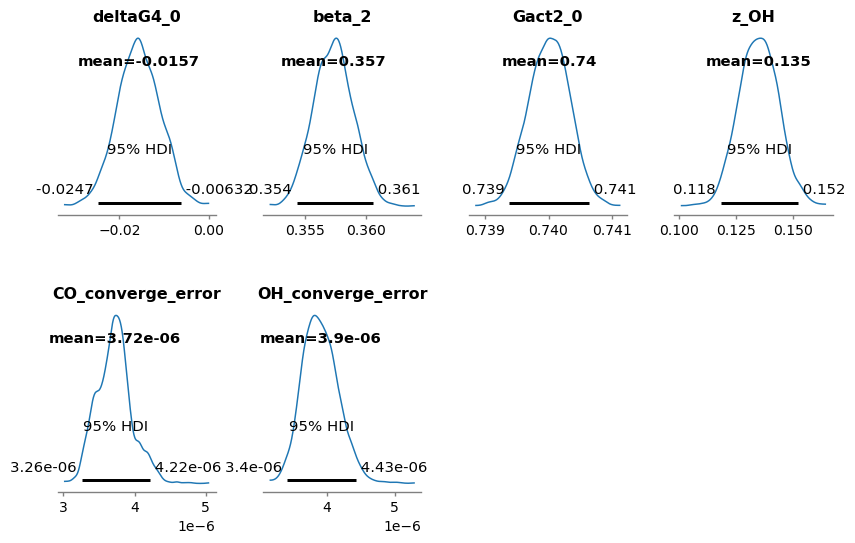

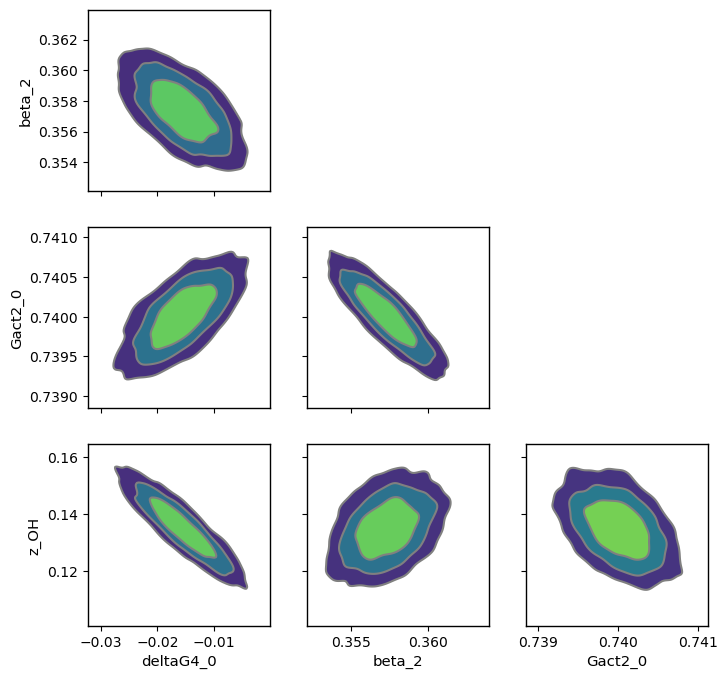

Sampling: [rate]


rate: 0.922


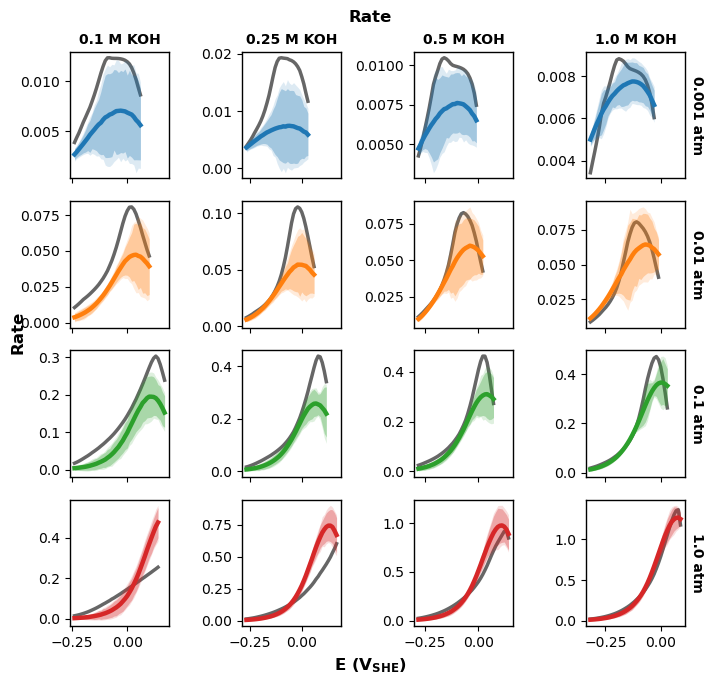

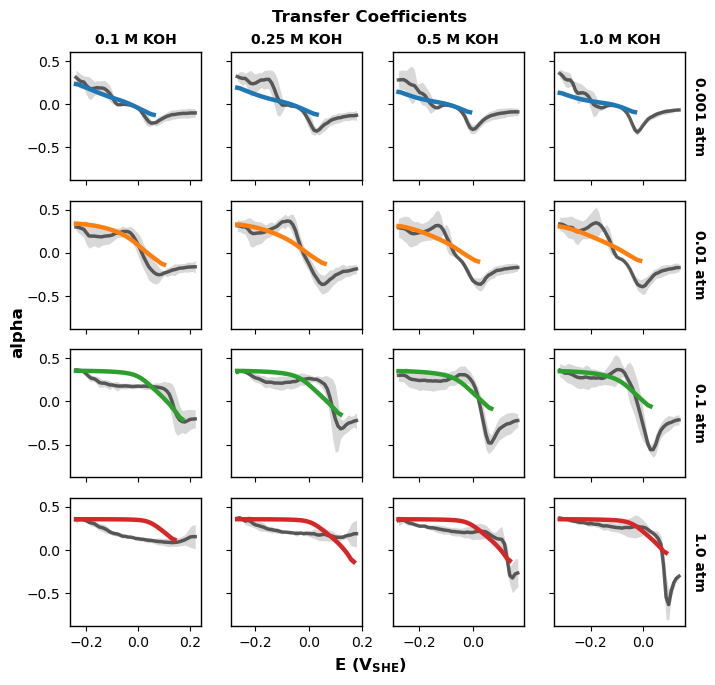

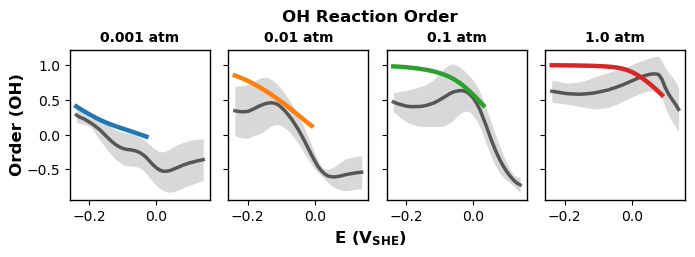

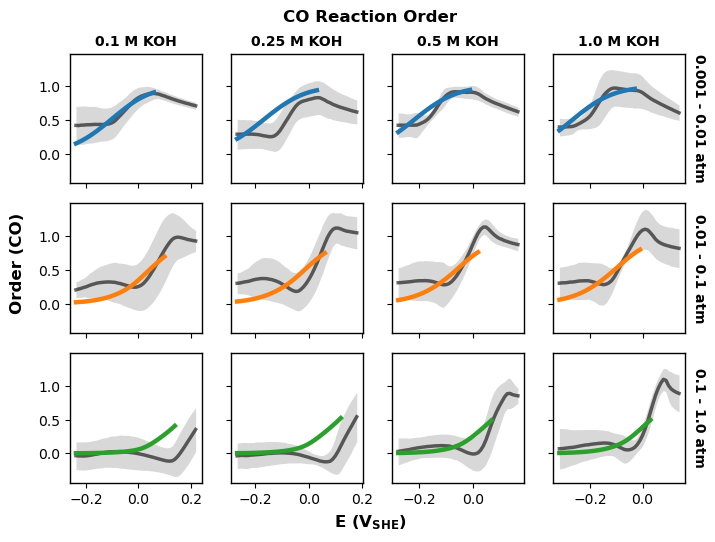

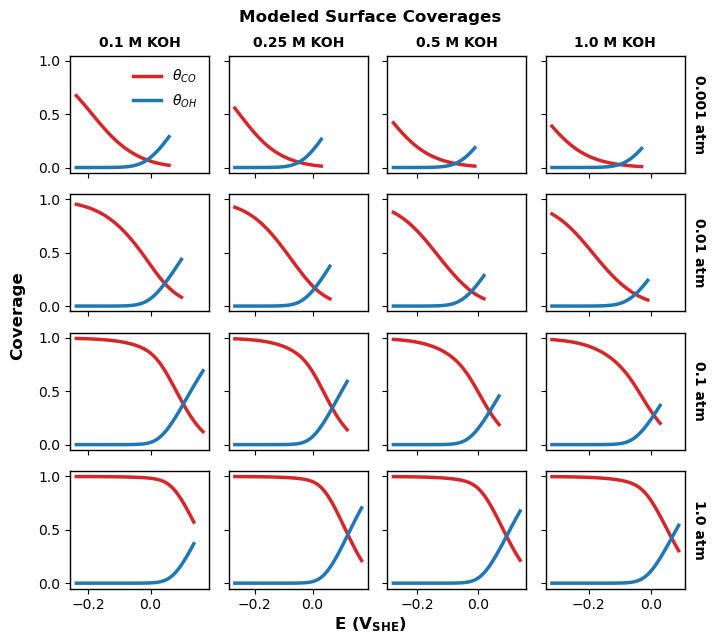

In [12]:
ppc_ER_1_2_lateral = plot_posteriors(trace_ER_1_2_lateral, ER_1_2_lateral, plot_target)
plot_model_fits(trace_ER_1_2_lateral, ppc_ER_1_2_lateral); plot_coverages(trace_ER_1_2_lateral)

# Comparison

                rank    elpd_loo      p_loo   elpd_diff        weight          se        dse  warning scale
ER_1_2_lateral     0 -203.496181  62.009162    0.000000  6.390685e-01  140.596201   0.000000     True   log
ER_1_2             1 -358.649324  70.102998  155.153143  1.527809e-14  162.354005  51.804622     True   log
ER_LH_1_2          2 -360.149927  72.025039  156.653746  3.609315e-01  162.618962  52.073942     True   log
ER_1_2_kin         3 -363.190312  74.896783  159.694132  0.000000e+00  163.380333  52.542910     True   log


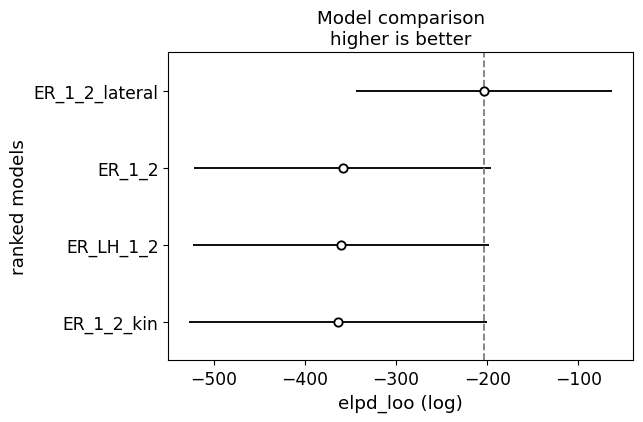

In [13]:
comparison_dict = {
    'ER_1_2': loo_ER_1_2,
    'ER_LH_1_2': loo_ER_LH_1_2,
    # 'ER_1_2_3': loo_ER_1_2_3, 
    'ER_1_2_kin': loo_ER_1_2_kin, 
    'ER_1_2_lateral': loo_ER_1_2_lateral,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()